# FSRCNN Training

## Objective

Train the FSRCNN model on the DIV2K dataset using the same training pipeline adopted for the SRCNN baseline.

The model is optimized using:

- Mean Squared Error (MSE) loss
- Adam optimizer
- Learning Rate Scheduler
- Early Stopping
- Model Checkpointing

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import json

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from src.models.fsrcnn import FSRCNN

from src.checkpoint import (
    save_model,
    save_checkpoint,
    load_checkpoint
)

from src.metrics import calculate_psnr

from src.dataloader import (
    get_train_loader,
    get_validation_loader
)

from src.train import train_one_epoch
from src.evaluate import evaluate

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [4]:
model = FSRCNN().to(device)

print(model)

FSRCNN(
  (feature_extraction): Sequential(
    (0): Conv2d(3, 56, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): PReLU(num_parameters=56)
  )
  (shrinking): Sequential(
    (0): Conv2d(56, 12, kernel_size=(1, 1), stride=(1, 1))
    (1): PReLU(num_parameters=12)
  )
  (mapping): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): PReLU(num_parameters=12)
    (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): PReLU(num_parameters=12)
    (4): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): PReLU(num_parameters=12)
    (6): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): PReLU(num_parameters=12)
  )
  (expanding): Sequential(
    (0): Conv2d(12, 56, kernel_size=(1, 1), stride=(1, 1))
    (1): PReLU(num_parameters=56)
  )
  (reconstruction): Conv2d(56, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


In [5]:
train_loader = get_train_loader()

validation_loader = get_validation_loader()

In [6]:
criterion = nn.MSELoss()

In [7]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [8]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,
    gamma=0.5
)

In [9]:
from src.checkpoint import save_model

TRAIN_EPOCHS = 200

best_psnr = 0.0

patience = 20
epochs_without_improvement = 0

train_loss_history = []
valid_loss_history = []
valid_psnr_history = []

for epoch in range(TRAIN_EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_psnr = evaluate(
        model=model,
        dataloader=validation_loader,
        criterion=criterion,
        device=device
    )

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_psnr_history.append(valid_psnr)

    print(
        f"Epoch {epoch+1}/{TRAIN_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Valid Loss: {valid_loss:.6f} | "
        f"PSNR: {valid_psnr:.2f} dB | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if valid_psnr > best_psnr:

        best_psnr = valid_psnr

        epochs_without_improvement = 0

        save_model(
            model,
            "../results/checkpoints/fsrcnn_best.pth"
        )

        print("Best model saved!")

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print("\nEarly stopping activated!")

        break

    scheduler.step()

Epoch 1/200 | Train Loss: 0.141978 | Valid Loss: 0.078576 | PSNR: 11.16 dB | LR: 0.000100
Best model saved!
Epoch 2/200 | Train Loss: 0.072922 | Valid Loss: 0.056593 | PSNR: 12.55 dB | LR: 0.000100
Best model saved!
Epoch 3/200 | Train Loss: 0.038906 | Valid Loss: 0.022635 | PSNR: 16.72 dB | LR: 0.000100
Best model saved!
Epoch 4/200 | Train Loss: 0.019431 | Valid Loss: 0.018808 | PSNR: 17.33 dB | LR: 0.000100
Best model saved!
Epoch 5/200 | Train Loss: 0.019105 | Valid Loss: 0.019578 | PSNR: 17.16 dB | LR: 0.000100
Epoch 6/200 | Train Loss: 0.019801 | Valid Loss: 0.014807 | PSNR: 18.37 dB | LR: 0.000100
Best model saved!
Epoch 7/200 | Train Loss: 0.017654 | Valid Loss: 0.017628 | PSNR: 17.75 dB | LR: 0.000100
Epoch 8/200 | Train Loss: 0.017123 | Valid Loss: 0.018480 | PSNR: 17.60 dB | LR: 0.000100
Epoch 9/200 | Train Loss: 0.015459 | Valid Loss: 0.017616 | PSNR: 17.87 dB | LR: 0.000100
Epoch 10/200 | Train Loss: 0.014621 | Valid Loss: 0.012502 | PSNR: 19.36 dB | LR: 0.000100
Best mode

In [10]:
from src.checkpoint import save_checkpoint

save_checkpoint(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    epoch=TRAIN_EPOCHS,
    best_psnr=best_psnr,
    filepath="../results/checkpoints/fsrcnn_training_checkpoint.pth"
)

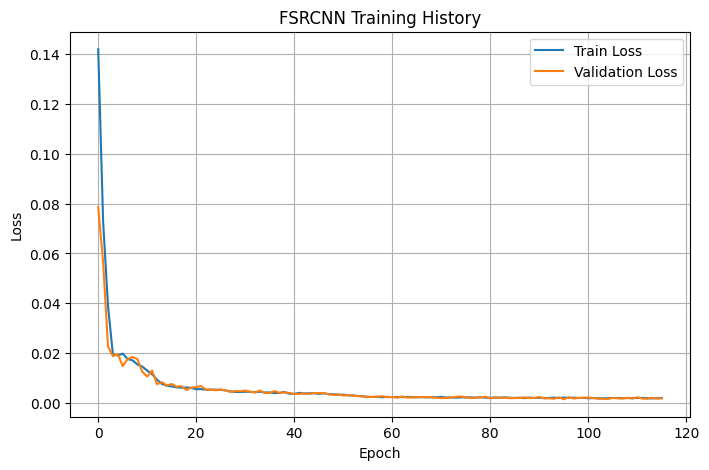

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FSRCNN Training History")

plt.legend()

plt.grid(True)

plt.show()

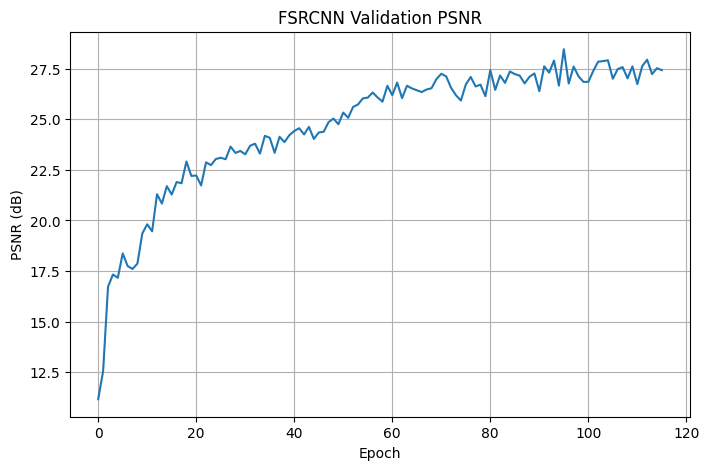

In [12]:
plt.figure(figsize=(8,5))

plt.plot(valid_psnr_history)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("FSRCNN Validation PSNR")

plt.grid(True)

plt.show()

In [13]:
import json

history = {

    "train_loss": train_loss_history,
    "valid_loss": valid_loss_history,
    "valid_psnr": valid_psnr_history

}

with open(
    "../results/metrics/fsrcnn_training_history.json",
    "w"
) as f:

    json.dump(history, f, indent=4)

print("Training history saved.")

Training history saved.


In [14]:
from src.checkpoint import save_model

save_model(
    model,
    "../results/checkpoints/fsrcnn_x2_200epochs.pth"
)

In [15]:
from src.checkpoint import load_model

model = load_model(
    model,
    "../results/checkpoints/fsrcnn_x2_200epochs.pth",
    device
)

c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)
